Q1 likelihood and loss
1.1 Show using derivation that maximizing likelihood under Laplacian error leads to minimizing
mean absolute error.
1.2 Identify the step in the derivation where the modeling assumption directly determines the
objective. What would change if the assumption changed?
1.3 If the error distribution becomes heavier-tailed than Laplacian, what qualitative change do you
expect in the loss function?
1.4 Given only training data, describe a procedure to decide whether MSE or MAE should be
minimized. Justify each step.

Q 1.1
Problem Statement
Show that maximizing likelihood under Laplacian error assumption leads to minimizing mean absolute error (MAE).
Mathematical Derivation
Step 1: Define the Model and Error Assumption
Model:
yᵢ = f(xᵢ; θ) + εᵢ
where:
yᵢ = observed target value
f(xᵢ; θ) = model prediction (e.g., xᵢᵀθ for linear regression)
εᵢ = error/noise term
θ = parameters we want to estimate
Error Assumption:
Each error εᵢ follows a Laplacian (Double Exponential) distribution:
εᵢ ~ Laplace(μ = 0, b)
where b > 0 is the scale parameter.

Step 2: Write the Laplacian Probability Density Function (PDF)
The Laplacian distribution with location μ = 0 and scale b has PDF:
p(εᵢ) = (1/2b) exp(-|εᵢ|/b)
Since εᵢ = yᵢ - f(xᵢ; θ), we can write:
p(yᵢ | xᵢ, θ) = (1/2b) exp(-|yᵢ - f(xᵢ; θ)|/b)
Key observation: The |·| (absolute value) appears inside the exponential!

Step 3: Write the Likelihood Function
Assuming N independent observations {(x₁, y₁), (x₂, y₂), ..., (xₙ, yₙ)}, the likelihood is:
L(θ, b | data) = ∏ᵢ₌₁ᴺ p(yᵢ | xᵢ, θ)
L(θ, b) = ∏ᵢ₌₁ᴺ [(1/2b) exp(-|yᵢ - f(xᵢ; θ)|/b)]
Separate constant and variable parts:
L(θ, b) = (1/2b)ᴺ · ∏ᵢ₌₁ᴺ exp(-|yᵢ - f(xᵢ; θ)|/b)

Step 4: Take the Natural Logarithm (Log-Likelihood)
Taking ln of both sides:
ln L(θ, b) = ln[(1/2b)ᴺ] + ln[∏ᵢ₌₁ᴺ exp(-|yᵢ - f(xᵢ; θ)|/b)]
ln L(θ, b) = N · ln(1/2b) + ∑ᵢ₌₁ᴺ ln[exp(-|yᵢ - f(xᵢ; θ)|/b)]
ln L(θ, b) = -N · ln(2b) + ∑ᵢ₌₁ᴺ [-|yᵢ - f(xᵢ; θ)|/b]
ln L(θ, b) = -N · ln(2b) - (1/b) ∑ᵢ₌₁ᴺ |yᵢ - f(xᵢ; θ)|

Step 5: Maximize with Respect to θ
To find the optimal parameters θ*, we maximize ln L(θ, b):
θ* = argmax_θ [ln L(θ, b)]
θ* = argmax_θ [-N · ln(2b) - (1/b) ∑ᵢ₌₁ᴺ |yᵢ - f(xᵢ; θ)|]
Key insight: The term -N · ln(2b) does NOT depend on θ, so we can drop it:
θ* = argmax_θ [-(1/b) ∑ᵢ₌₁ᴺ |yᵢ - f(xᵢ; θ)|]

Step 6: Simplify the Optimization
Since b > 0 is a positive constant, we can pull it out:
Maximizing -(1/b) · [something] is the same as minimizing [something].
Therefore:
θ* = argmin_θ [∑ᵢ₌₁ᴺ |yᵢ - f(xᵢ; θ)|]

Step 7: Connect to Mean Absolute Error (MAE)
The Mean Absolute Error is defined as:
MAE(θ) = (1/N) ∑ᵢ₌₁ᴺ |yᵢ - f(xᵢ; θ)|
Since 1/N is a positive constant, minimizing ∑|·| is equivalent to minimizing MAE.

 Conclusion
Maximizing likelihood under Laplacian errors ⟺ Minimizing MAE

Mathematically:
argmax_θ L(θ) = argmin_θ (1/N) ∑ᵢ₌₁ᴺ |yᵢ - f(xᵢ; θ)|
This proves that MAE is the natural loss function when we believe our errors follow a Laplacian distribution.

Q 1.2
Part 1: Identify the Critical Step
The critical step is Step 2: Writing the Probability Density Function where we specify the error distribution.
Specifically:
For Laplacian: p(ε) = (1/2b) exp(-|ε|/b)
The |ε| inside the exponential directly determines that the loss will be absolute error
This step is critical because:
It's where the modeling assumption about the error distribution is encoded
The function inside the exponential becomes the loss function (after taking log)
All subsequent steps are deterministic mathematical manipulations
Changing this step changes everything downstream.
Part 2: What Changes If Assumption Changes?
If we change the error distribution assumption at Step 2, the resulting loss function changes according to what's inside the exponential:
Pattern:
If p(ε) ∝ exp(-g(ε)) → Loss function = g(ε)
Specific Examples:
Gaussian assumption (ε² in exponential)
- MSE loss: Σ(yᵢ - f(xᵢ))²
Good for: symmetric errors, no outliers
Laplacian assumption (|ε| in exponential)
- MAE loss: Σ|yᵢ - f(xᵢ)|
Good for: moderate outliers, robust to noise
Uniform assumption (constant in range)
- Minimax loss: min max|yᵢ - f(xᵢ)|
Good for: worst-case guarantees
Cauchy assumption (log(1+ε²) effectively)
- Logarithmic loss: Σ log(1 + (yᵢ-f(xᵢ))²)
Good for: heavy-tailed errors, extreme outliers
- The loss function is NOT an arbitrary choice - it should reflect your beliefs about how errors are distributed in your data!

Q 1.3
If the error distribution becomes heavier-tailed than Laplacian, I expect the following qualitative changes in the loss function:
Slower Growth Rate:
The loss should grow sub-linearly (slower than |ε|) for large errors
Likely logarithmic growth: L(ε) ∝ log(1 + ε²) instead of linear L(ε) ∝ |ε|
Reduced Sensitivity to Outliers:
Large errors receive relatively less penalty
The gradient L'(ε) → 0 as ε → ∞ (instead of staying constant like MAE)
This makes the estimator more robust to extreme values
Potential Non-Convexity:
The loss function may become non-convex or very flat for large errors
This can create optimization challenges (multiple local minima or slow convergence)
May require better initialization or more sophisticated optimization
Mathematical Form:
For Cauchy-like heavy tails: L(ε) = log(1 + ε²/γ²)
For Student-t: Similar log-based forms
For bounded influence (Tukey): L(ε) may plateau at a constant value
Intuition: Since heavy-tailed distributions expect outliers to occur frequently, the loss function shouldn't "freak out" about them. It grows slowly or even plateaus for large errors, treating them as a normal part of the data rather than as catastrophic failures.
Example: For an error ε = 100:
MSE penalty: 10,000 (very severe)
MAE penalty: 100 (moderate)
Cauchy loss penalty: ≈ 9.2 (very mild)
This reflects that under heavy-tailed assumptions, extreme observations are expected and shouldn't dominate the optimization.

Q 1.4
Given only training data, here is a systematic procedure to decide whether MSE or MAE should be minimized:

Step 1: Fit a Baseline Model
Use ordinary least squares to get initial weights: w₀ = (X^T X)^(-1) X^T y
Justification: Need an initial model to extract residuals; OLS is simple and fast
Step 2: Calculate Residuals
Compute rᵢ = yᵢ - xᵢ^T w₀ for all training points
Justification: Residuals approximate the true error distribution
Step 3: Visualize Residual Distribution
Create histogram with Gaussian and Laplacian overlays
Generate Q-Q plots for both distributions
Justification: Visual inspection reveals tail behavior; Q-Q plots show deviations from theoretical distributions
Step 4: Compute Kurtosis
Calculate excess kurtosis of residuals
Decision: kurt ≈ 0 → MSE; kurt ≈ 3 → MAE; kurt > 5 → robust loss
Justification: Kurtosis quantifies tail heaviness; Gaussian has kurt=0, Laplacian has kurt=3
Step 5: Analyze Outlier Fraction
Count points beyond 3 standard deviations
Check percentile ratios (95th/median, 99th/median)
Justification: Gaussian expects ~0.3% outliers, Laplacian ~1.2%; higher fractions indicate heavier tails
Step 6: Statistical Hypothesis Tests
Shapiro-Wilk test for normality (p > 0.05 → cannot reject Gaussian)
K-S test for Laplacian fit
Justification: Provides statistical rigor; p-values give confidence in distribution choice
Step 7: Cross-Validation Comparison
Train models with both MSE and MAE objectives using K-fold CV
Compare validation performance
Justification: Empirical test of which loss generalizes better; ultimate practical criterion
Step 8: Combine Evidence
Use majority vote across all tests
If still ambiguous, default to MAE (more robust)
Justification: Multiple perspectives reduce risk of incorrect choice
This procedure reverse-engineers the MLE principle. Since Gaussian errors → MSE via MLE and Laplacian errors → MAE via MLE, we observe the empirical error distribution and choose the loss function that corresponds to that distribution's MLE.

module 2 : Building nuts and bolts in python 

Q2 1. Implement a data generator with
• inputs: n sample, cov matrix, wt vector, error dist type, error dist param
• outputs: feature matrix X and targets t.
• You must write the mathematical generative model in equations before coding.
• Requirements:
– each feature marginally standard normal
– covariance matches cov matrix
– add Gaussian / Laplacian / uniform noise
– validate covariance (symmetric, PSD, diagonal = 1)
– if the weight dimension is one more than that of data then add a column of 1’s
– plot ideal vs noisy output
2. show at least one visualization of two negatively correlated features using a scatter plot
3. Implement gradient descent with L1/L2 regularization
4. Implement ridge pseudo-inverse estimator
5. Build inference module with optional NRMSE/NMAE
6. Test on synthetic data.

module 3 Optimization and Estimation 

1. Implement gradient descent with L1/L2 regularization
2. Implement ridge pseudo-inverse estimator
3. Build inference module with optional NRMSE/NMAE
Test on synthetic data.
Pre-question
Which estimator do you expect to be more stable: gradient descent or pseudo-inverse? Why?
Post-question
When do the two estimators disagree and why?
Rubric
• 0.75: correct gradient descent behavior
• 0.75: correct ridge estimator
• 0.5: correct inference + metrics

Module 4 Bias–Variance Experiments

Tasks
Using Gaussian and Laplacian noise:
1. Show variance shrinks as N increases
2. Show MSE beats MAE under Gaussian noise
3. Show MAE beats MSE under Laplacian noise
Fix validation data. Fix training data size only (not the data itself). Use repeated resampling of
training data. Train model for each resampling of training data and compute output on validation
data. For each validation sample, compute variance in output (simply the statistical variance), and
take average variance across validation samples.
Pre-question
Which result do you expect to change faster with increasing N: bias or variance?
Post-question
Which result contradicted your intuition?

module 5 Regularization Behavior

Tasks
1. Empirically confirm that validation error minimized at λ>0
2. Demonstrate L1 variable elimination
3. Show instability with correlated features and stabilization via L2
Pre-question
Why should λ= 0 almost never be optimal?
Post-question
When does L1 fail to stabilize correlated features?

Gaussian Noise Stats:
Mean noise: 0.041097059776002795
Std noise : 0.497506976901152


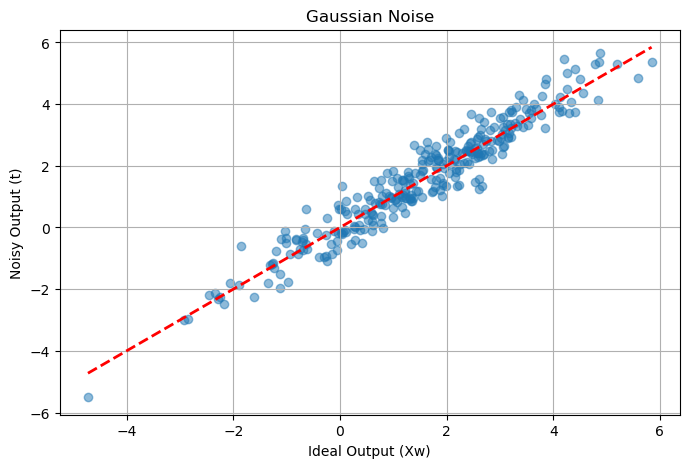


Laplacian Noise Stats:
Mean noise: 0.006986003835203416
Std noise : 0.3884856358233577


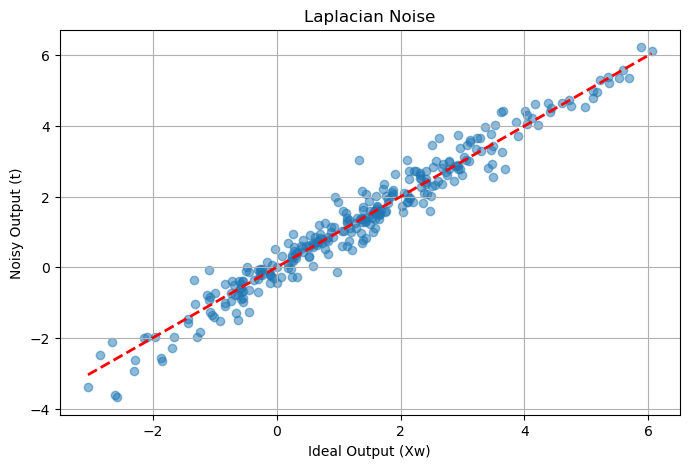


Uniform Noise Stats:
Mean noise: -0.03100251792617822
Std noise : 0.44775061143294664


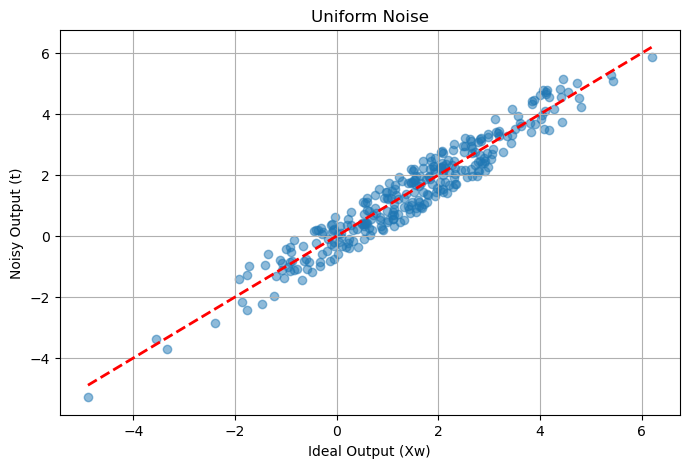

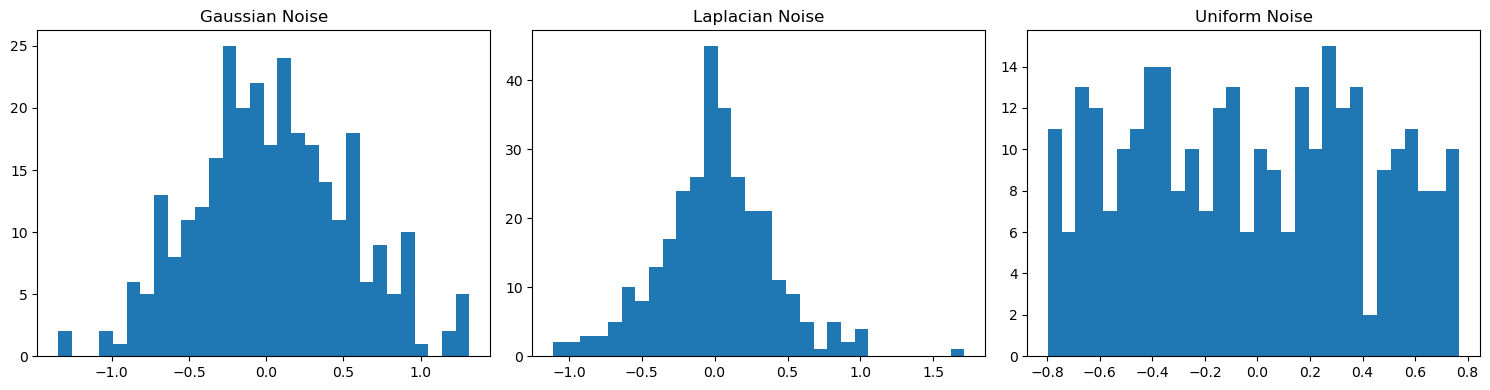


✅ Data generation demo complete!


In [1]:
# =========================================================
# IMPORTS
# =========================================================
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# DATA GENERATOR FUNCTION
# =========================================================
def generate_data(n_sample, cov_matrix, wt_vector,
                  error_dist_type='gaussian',
                  error_dist_param=0.5):

    cov_matrix = np.array(cov_matrix)
    wt_vector = np.array(wt_vector)

    # ----- Validation -----
    if not np.allclose(cov_matrix, cov_matrix.T):
        raise ValueError("Covariance matrix must be symmetric.")

    if not np.allclose(np.diag(cov_matrix), 1.0):
        raise ValueError("Diagonal must be 1 for standard normal marginals.")

    eigvals = np.linalg.eigvals(cov_matrix)
    if np.any(eigvals < -1e-10):
        raise ValueError("Covariance must be Positive Semi-Definite.")

    d = cov_matrix.shape[0]

    if len(wt_vector) not in [d, d+1]:
        raise ValueError("Weight dimension mismatch.")

    # ----- Feature Generation -----
    mean = np.zeros(d)
    X = np.random.multivariate_normal(mean, cov_matrix, size=n_sample)

    # ----- Bias Handling -----
    if len(wt_vector) == d + 1:
        X_with_bias = np.hstack([np.ones((n_sample,1)), X])
    else:
        X_with_bias = X

    # ----- Noise Generation -----
    if error_dist_type == 'gaussian':
        noise = np.random.normal(0, error_dist_param, size=n_sample)

    elif error_dist_type == 'laplacian':
        noise = np.random.laplace(0, error_dist_param, size=n_sample)

    elif error_dist_type == 'uniform':
        noise = np.random.uniform(-error_dist_param,
                                   error_dist_param,
                                   size=n_sample)
    else:
        raise ValueError("Unsupported error_dist_type.")

    # ----- Outputs -----
    ideal_t = X_with_bias @ wt_vector
    t = ideal_t + noise

    return X, t, ideal_t


# =========================================================
# VISUALIZATION FUNCTION
# =========================================================
def plot_results(ideal_t, noisy_t, title="Ideal vs Noisy Output"):

    plt.figure(figsize=(8,5))
    plt.scatter(ideal_t, noisy_t, alpha=0.5)
    plt.plot([ideal_t.min(), ideal_t.max()],
             [ideal_t.min(), ideal_t.max()],
             'r--', lw=2)

    plt.xlabel('Ideal Output (Xw)')
    plt.ylabel('Noisy Output (t)')
    plt.title(title)
    plt.grid(True)
    plt.show()


# =========================================================
# MAIN DEMO EXECUTION (NOTEBOOK FRIENDLY)
# =========================================================

np.random.seed(42)

n_sample = 300
cov_matrix = [[1.0, 0.5],
              [0.5, 1.0]]

wt_vector = [1.5, 2.0, -1.0]  # [bias, w1, w2]


# -------------------------------
# Example 1: Gaussian Noise
# -------------------------------
X, t, ideal_t = generate_data(
    n_sample,
    cov_matrix,
    wt_vector,
    error_dist_type='gaussian',
    error_dist_param=0.5
)

print("Gaussian Noise Stats:")
print("Mean noise:", np.mean(t - ideal_t))
print("Std noise :", np.std(t - ideal_t))

plot_results(ideal_t, t, "Gaussian Noise")


# -------------------------------
# Example 2: Laplacian Noise
# -------------------------------
X2, t2, ideal_t2 = generate_data(
    n_sample,
    cov_matrix,
    wt_vector,
    error_dist_type='laplacian',
    error_dist_param=0.3
)

print("\nLaplacian Noise Stats:")
print("Mean noise:", np.mean(t2 - ideal_t2))
print("Std noise :", np.std(t2 - ideal_t2))

plot_results(ideal_t2, t2, "Laplacian Noise")


# -------------------------------
# Example 3: Uniform Noise
# -------------------------------
X3, t3, ideal_t3 = generate_data(
    n_sample,
    cov_matrix,
    wt_vector,
    error_dist_type='uniform',
    error_dist_param=0.8
)

print("\nUniform Noise Stats:")
print("Mean noise:", np.mean(t3 - ideal_t3))
print("Std noise :", np.std(t3 - ideal_t3))

plot_results(ideal_t3, t3, "Uniform Noise")


# =========================================================
# NOISE DISTRIBUTION COMPARISON
# =========================================================

fig, axes = plt.subplots(1,3, figsize=(15,4))

noise1 = t - ideal_t
noise2 = t2 - ideal_t2
noise3 = t3 - ideal_t3

axes[0].hist(noise1, bins=30)
axes[0].set_title("Gaussian Noise")

axes[1].hist(noise2, bins=30)
axes[1].set_title("Laplacian Noise")

axes[2].hist(noise3, bins=30)
axes[2].set_title("Uniform Noise")

plt.tight_layout()
plt.show()

print("\n✅ Data generation demo complete!")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [8]:
def valid_covariance(Sigma):
  if not np.allclose(Sigma,Sigma.T):
    print ("not symmetric")
    return False

  if np.any(np.linalg.eigvals(Sigma)<0):
    print ('not PSD')
    return False

  if not np.allclose(np.diag(Sigma),1):
    print ("non singular diagonal")
    return False

  print ("Covariance matrix is valid")
  return True

In [84]:
def generate_standard_normal(n_samples = 500, n_features = 2):
   Sigma = np.array([[1, 0.8],[0.8, 1]])
   X = np.random.multivariate_normal(mean=np.zeros(n_features),cov=Sigma, size=n_samples)
   return X


In [85]:
X = generate_standard_normal(n_samples = 500, n_features = 2)

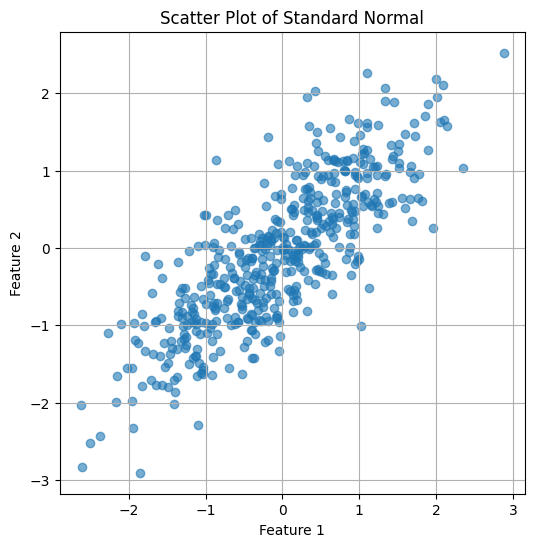

In [86]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], alpha=0.6)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Scatter Plot of Standard Normal")
plt.grid(True)
plt.show()

In [12]:
def generate_negative_normal(n_samples = 500, n_features = 2):
  Sigma_neg = np.array([[1, -0.8],[-0.8, 1]])
  X_neg = np.random.multivariate_normal(mean=np.zeros(n_features),cov=Sigma_neg,size=n_samples)
  return X_neg

In [13]:
w = np.array([2, -3])

In [14]:
y_ideal = X @ w

In [15]:
def generate_uniform_noise(n_samples, noise_range = 0.5):
    return np.random.uniform(-noise_range, noise_range, n_samples)

In [16]:
def generate_target(X, w, noise_range = 0.5):
    noise = generate_uniform_noise(len(X), noise_range)
    t = X @ w + noise
    return t

In [17]:
t = generate_target(X, w, noise_range=0.5)

print("Shape of X:", X.shape)
print("First 5 feature samples:\n", X[:5])
print("First 5 targets:\n", t[:5])
print(X[:,0].shape)
print(y_ideal.shape)
print(t.shape)

Shape of X: (500, 2)
First 5 feature samples:
 [[ 1.12462441  0.44310353]
 [-0.77397639 -1.58081984]
 [-0.84508687  0.77518686]
 [ 0.50773258  0.35160965]
 [-0.54362635  0.98110309]]
First 5 targets:
 [ 0.66490161  3.03936285 -3.53161931  0.14886544 -4.22960248]
(500,)
(500,)
(500,)


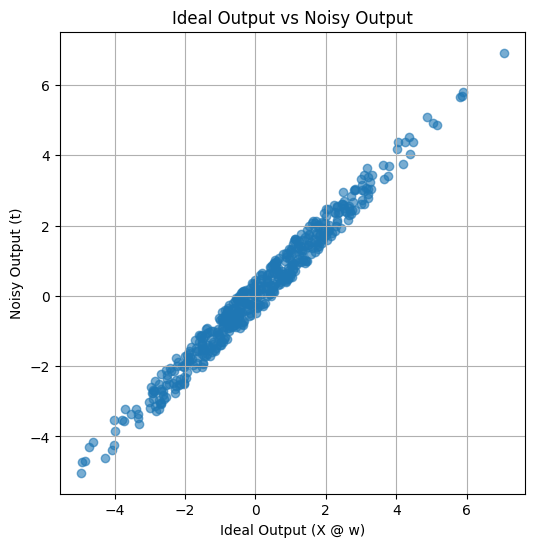

In [18]:
plt.figure(figsize=(6,6))

plt.scatter(y_ideal, t, alpha=0.6)

plt.xlabel("Ideal Output (X @ w)")
plt.ylabel("Noisy Output (t)")
plt.title("Ideal Output vs Noisy Output")
plt.grid(True)

plt.show()



In [19]:
X_neg = generate_negative_normal(n_samples=500, n_features=2)

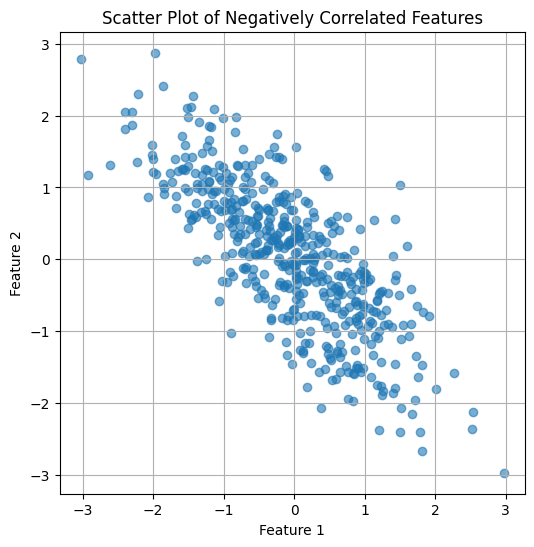

In [20]:
plt.figure(figsize=(6,6))
plt.scatter(X_neg[:,0], X_neg[:,1], alpha=0.6)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Scatter Plot of Negatively Correlated Features")
plt.grid(True)

plt.show()

In [21]:
def gradient_descent_l2(X, t, lr=0.01, lambda_=0.1, iterations=1000):
    n, d = X.shape
    w = np.zeros(d)
    losses = []

    for i in range(iterations):
        y_pred = X @ w
        error = y_pred - t

        grad = (2/n) * X.T @ error + 2 * lambda_ * w
        w = w - lr * grad

        mse = np.mean(error**2)
        loss = mse + lambda_ * np.sum(w**2)
        losses.append(loss)

    return w, losses


In [22]:
w_l2, losses_l2 = gradient_descent_l2(
    X, t,
    lr=0.01,
    lambda_=0.1,
    iterations=500
)

print("True weights:", w)
print("L2 estimated weights:", w_l2)

True weights: [ 2 -3]
L2 estimated weights: [ 1.1786263  -2.10625179]


In [23]:
w_l2, losses_l2 = gradient_descent_l2(
    X, t,
    lr=0.01,
    lambda_=0.001,
    iterations=1000
)

print("True weights:", w)
print("L2 estimated weights:", w_l2)

True weights: [ 2 -3]
L2 estimated weights: [ 1.94872742 -2.91654854]


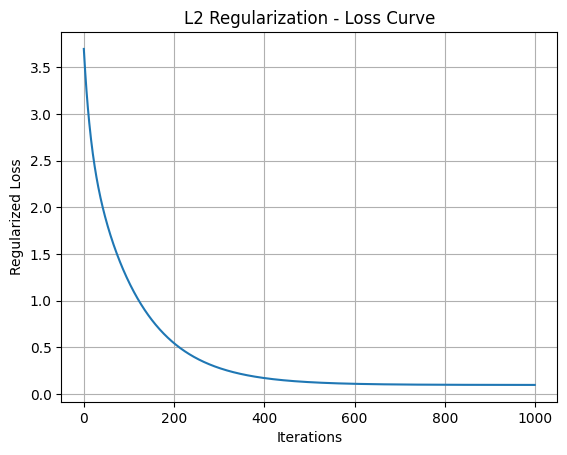

In [24]:
plt.plot(losses_l2)
plt.title("L2 Regularization - Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Regularized Loss")
plt.grid(True)
plt.show()


In [25]:
def ridge_pseudo_inverse(X, t, lambda_=0.1):

    n, d = X.shape

    I = np.eye(d)  # Identity matrix

    # Ridge formula
    w = np.linalg.inv(X.T @ X + lambda_ * I) @ X.T @ t

    return w


In [26]:
w_ridge = ridge_pseudo_inverse(X, t, lambda_=0.1)

print("True weights:", w)
print("L2 GD weights:", w_l2)
print("Ridge closed-form weights:", w_ridge)
print("Difference between GD and Ridge:", np.linalg.norm(w_l2 - w_ridge))



True weights: [ 2 -3]
L2 GD weights: [ 1.94872742 -2.91654854]
Ridge closed-form weights: [ 1.98473806 -2.95238636]
Difference between GD and Ridge: 0.050804679697502395


In [27]:
def inference_nrmse(X, w, y_true):

    # Prediction
    y_pred = X @ w

    # Compute RMSE
    rmse = np.sqrt(np.mean((y_pred - y_true)**2))

    # Normalize
    nrmse = rmse / (np.max(y_true) - np.min(y_true))

    return y_pred, nrmse


In [28]:
y_pred_l2, nrmse_l2 = inference_nrmse(X, w_l2, t)

print("NRMSE (L2 GD):", nrmse_l2)


NRMSE (L2 GD): 0.02417367792337145


In [29]:
y_pred_ridge, nrmse_ridge = inference_nrmse(X, w_ridge, t)

print("NRMSE (Ridge Closed-Form):", nrmse_ridge)


NRMSE (Ridge Closed-Form): 0.02407958389408756


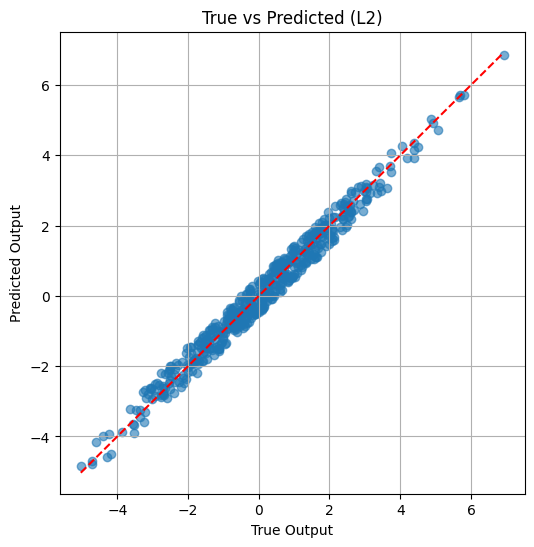

In [87]:
plt.figure(figsize=(6,6))
plt.scatter(t, y_pred_l2, alpha=0.6)

min_val = min(t.min(), y_pred_l2.min())
max_val = max(t.max(), y_pred_l2.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("True Output")
plt.ylabel("Predicted Output")
plt.title("True vs Predicted (L2)")
plt.grid(True)
plt.show()


In [31]:
def variance_experiment(train_sizes, num_resamples = 30):
  avg_variances = []

  X_val = generate_standard_normal(200, 2)
  y_val = generate_target(X_val, w, noise_range=0.5)

  for N in train_sizes:
        predictions = []

        for _ in range(num_resamples):

            # Resample training data
            X_train = generate_standard_normal(N, 2)
            y_train = generate_target(X_train, w, noise_range=0.5)

            # Train ridge
            w_hat = ridge_pseudo_inverse(X_train, y_train, lambda_=0.1)

            # Predict on validation
            y_pred = X_val @ w_hat
            predictions.append(y_pred)

        predictions = np.array(predictions)

        # Variance across models (axis=0 → per validation sample)
        var_per_sample = np.var(predictions, axis=0)

        # Average variance
        avg_variances.append(np.mean(var_per_sample))

  return avg_variances


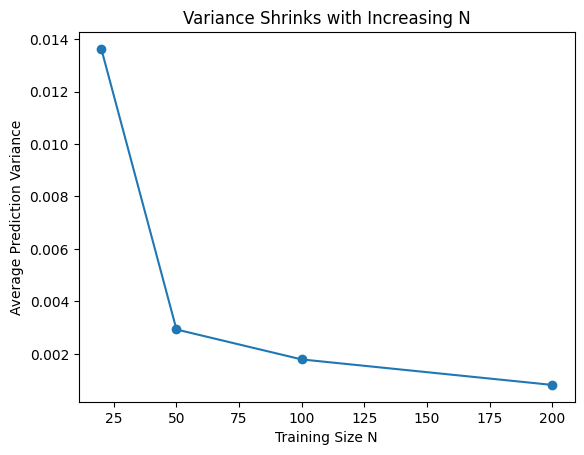

In [32]:
train_sizes = [20, 50, 100, 200]
variances = variance_experiment(train_sizes)
plt.plot(train_sizes, variances, marker='o')
plt.xlabel("Training Size N")
plt.ylabel("Average Prediction Variance")
plt.title("Variance Shrinks with Increasing N")
plt.show()


In [33]:
def generate_gaussian_target(X, w, sigma=0.5):
    noise = np.random.normal(0, sigma, len(X))
    return X @ w + noise

In [34]:
# Training data
X_train = generate_standard_normal(200, 2)
y_train = generate_gaussian_target(X_train, w, sigma=0.5)

# Train using MSE (Ridge)
w_mse = ridge_pseudo_inverse(X_train, y_train, lambda_=0.01)


In [46]:
def gradient_descent_mae(X, y, lr=0.01, iterations=300):

    n, d = X.shape
    w = np.zeros(d)

    for _ in range(iterations):
        error = X @ w - y

        # Subgradient of MAE
        grad = (1/n) * X.T @ np.sign(error)

        w = w - lr * grad

    return w


In [47]:
w_mae = gradient_descent_mae(X_train, y_train, lr=0.01, iterations=300)


In [48]:
# Fixed validation set
X_val = generate_standard_normal(300, 2)
y_val = generate_gaussian_target(X_val, w, sigma=0.5)

# Predictions
y_pred_mse = X_val @ w_mse
y_pred_mae = X_val @ w_mae

# Compute MSE
mse_mse = np.mean((y_pred_mse - y_val)**2)
mse_mae = np.mean((y_pred_mae - y_val)**2)

print("Validation MSE (MSE-trained model):", mse_mse)
print("Validation MSE (MAE-trained model):", mse_mae)


Validation MSE (MSE-trained model): 0.2508770136433671
Validation MSE (MAE-trained model): 1.6473276357855233


In [61]:
def generate_laplace_target(X, w, scale=0.5):
    noise = np.random.laplace(0, scale, len(X))
    return X @ w + noise


In [66]:
# Training data
X_train = generate_standard_normal(200, 2)
y_train = generate_laplace_target(X_train, w, scale=0.5)

# Model A: MSE (Ridge)
w_mse = ridge_pseudo_inverse(X_train, y_train, lambda_=0.01)

# Model B: MAE (L1 GD)
w_mae = gradient_descent_mae(X_train, y_train, lr=0.01, iterations=2000)


In [67]:
# Validation data (fixed)
X_val = generate_standard_normal(300, 2)
y_val = generate_laplace_target(X_val, w, scale=0.5)

# Predictions
y_pred_mse = X_val @ w_mse
y_pred_mae = X_val @ w_mae

# Compute MAE
mae_mse = np.mean(np.abs(y_pred_mse - y_val))
mae_mae = np.mean(np.abs(y_pred_mae - y_val))

print("Validation MAE (MSE-trained model):", mae_mse)
print("Validation MAE (MAE-trained model):", mae_mae)


Validation MAE (MSE-trained model): 0.48414652567949135
Validation MAE (MAE-trained model): 0.48135671853446826


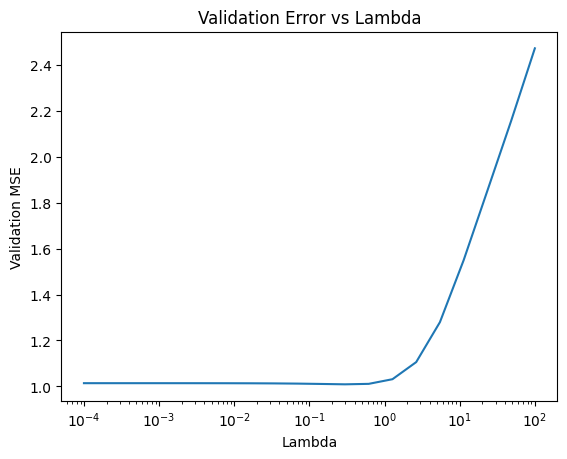

In [89]:
# More features, small data
w_true = np.array([2, -3])
X_train = generate_standard_normal(30, 2)
y_train = generate_gaussian_target(X_train, w_true, sigma=1.0)

X_val = generate_standard_normal(30, 2)
y_val = generate_gaussian_target(X_val, w_true, sigma=1.0)

lambdas = np.logspace(-4, 2, 20)
val_errors = []

for lam in lambdas:
    w_hat = ridge_pseudo_inverse(X_train, y_train, lambda_=lam)
    y_pred = X_val @ w_hat
    val_errors.append(np.mean((y_pred - y_val)**2))

plt.semilogx(lambdas, val_errors)
plt.xlabel("Lambda")
plt.ylabel("Validation MSE")
plt.title("Validation Error vs Lambda")
plt.show()


In [96]:
def generate_standard_normal_2(n_samples = 500, n_features = 6):
   Sigma = np.eye(n_features)
   X = np.random.multivariate_normal(mean=np.zeros(n_features),cov=Sigma, size=n_samples)
   return X

In [97]:
w_true = np.array([2, -3, 0, 0, 0, 0])

X_train = generate_standard_normal_2(200, 6)
y_train = generate_gaussian_target(X_train, w_true, sigma=0.5)


In [98]:
def gradient_descent_l1(X, y, lr=0.01, lambda_=0.1, iterations=300):

    n, d = X.shape
    w = np.zeros(d)

    for _ in range(iterations):

        error = X @ w - y

        # MSE gradient
        grad = (2/n) * X.T @ error

        # L1 subgradient
        grad += lambda_ * np.sign(w)

        w = w - lr * grad

    return w


In [102]:
w_l1 = gradient_descent_l1(
    X_train, y_train,
    lr=0.01,
    lambda_=0.5,
    iterations=300
)

print("True weights:", w_true)
print("L1 estimated weights:", w_l1)
print(np.round(w_l1,4))

True weights: [ 2 -3  0  0  0  0]
L1 estimated weights: [ 1.75226048e+00 -2.80366151e+00 -2.89705317e-03  1.93131934e-03
 -3.45631740e-03  2.42334911e-03]
[ 1.7523e+00 -2.8037e+00 -2.9000e-03  1.9000e-03 -3.5000e-03  2.4000e-03]


In [103]:
lambdas = np.logspace(-3, 1, 20)  # from 0.001 to 10

weights = []

for lam in lambdas:

    w_l1 = gradient_descent_l1(
        X_train, y_train,
        lr=0.01,
        lambda_=lam,
        iterations=2000
    )

    weights.append(w_l1)

weights = np.array(weights)


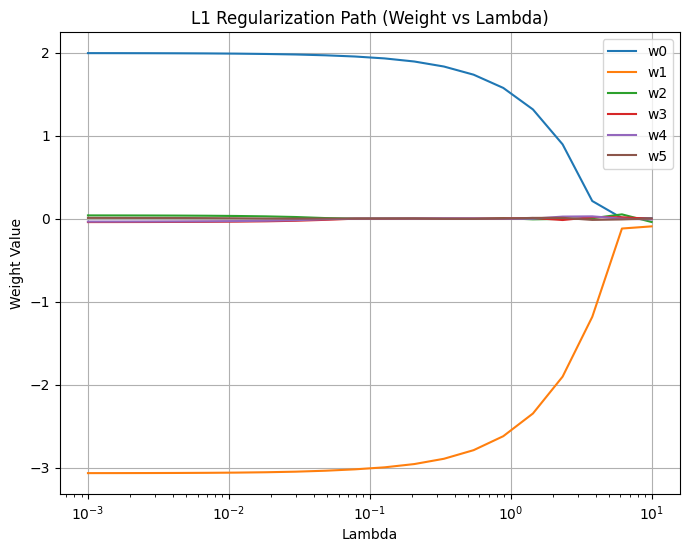

In [104]:
plt.figure(figsize=(8,6))

for i in range(weights.shape[1]):
    plt.plot(lambdas, weights[:, i], label=f'w{i}')

plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Weight Value")
plt.title("L1 Regularization Path (Weight vs Lambda)")
plt.legend()
plt.grid(True)
plt.show()


In [105]:
# Highly correlated covariance
Sigma_corr = np.array([[1, 0.99],
                       [0.99, 1]])

def generate_correlated(n_samples):
    return np.random.multivariate_normal(
        mean=[0, 0],
        cov=Sigma_corr,
        size=n_samples
    )

w_true = np.array([2, -3])


In [106]:
weights_no_reg = []

for _ in range(20):

    X_train = generate_correlated(50)
    y_train = generate_gaussian_target(X_train, w_true, sigma=0.5)

    w_hat = ridge_pseudo_inverse(X_train, y_train, lambda_=0)
    weights_no_reg.append(w_hat)

weights_no_reg = np.array(weights_no_reg)

print("Weights without regularization:")
print(weights_no_reg)


Weights without regularization:
[[ 2.30456463 -3.28545687]
 [ 2.22969777 -3.05180804]
 [ 2.76253516 -3.75220473]
 [ 1.18045907 -2.0798501 ]
 [ 2.41973659 -3.33005686]
 [ 1.41510709 -2.38112941]
 [ 1.76114853 -2.79502541]
 [ 1.87917196 -2.97667116]
 [ 2.67024762 -3.75481247]
 [ 2.86773199 -3.83230115]
 [ 1.57370779 -2.46938902]
 [ 1.86773793 -3.00565698]
 [ 3.43755102 -4.39941231]
 [ 2.42313016 -3.33934691]
 [ 2.18119442 -3.15969625]
 [ 2.35094514 -3.40160623]
 [ 2.32478405 -3.41763667]
 [ 2.66019964 -3.61242842]
 [ 2.81030421 -3.71247306]
 [ 2.18787298 -3.14591624]]


In [107]:
weights_l2 = []

for _ in range(20):

    X_train = generate_correlated(50)
    y_train = generate_gaussian_target(X_train, w_true, sigma=0.5)

    w_hat = ridge_pseudo_inverse(X_train, y_train, lambda_=0.5)
    weights_l2.append(w_hat)

weights_l2 = np.array(weights_l2)

print("Weights with L2:")
print(weights_l2)


Weights with L2:
[[ 1.15934645 -2.19600047]
 [ 1.29549562 -2.27840346]
 [ 0.46492072 -1.46591381]
 [ 0.9428634  -1.90299038]
 [ 0.37246722 -1.30374983]
 [ 0.70438987 -1.64028962]
 [ 0.49880419 -1.51551145]
 [ 0.61669612 -1.71683205]
 [ 0.77180228 -1.69464309]
 [ 0.71381759 -1.76064439]
 [ 1.08181148 -2.03090009]
 [ 0.65324637 -1.59404697]
 [ 0.84167663 -1.7931665 ]
 [ 1.03569579 -2.11600207]
 [ 0.69440703 -1.7272163 ]
 [ 0.7195354  -1.76167444]
 [ 0.21298918 -1.20690831]
 [ 0.77516932 -1.75460979]
 [ 0.84545005 -1.8136843 ]
 [ 1.31208635 -2.30883467]]


In [108]:
print("Variance without reg:", np.var(weights_no_reg, axis=0))
print("Variance with L2:", np.var(weights_l2, axis=0))


Variance without reg: [0.28080682 0.28559955]
Variance with L2: [0.0806519  0.08433813]


Bonus Module — Insight Extension 

• Implement Huber loss and compare


Prediction:
Huber loss should behave like MSE for small errors and MAE for large errors.
It is expected to perform well when noise contains moderate outliers.

Reflection:
We compare Huber loss against MSE and MAE models on validation data.


In [2]:
# =========================================================
# HUBER LOSS GRADIENT DESCENT
# =========================================================

def gradient_descent_huber(X, y, delta=1.0, lr=0.01, iterations=500):

    n, d = X.shape
    w = np.zeros(d)

    for _ in range(iterations):

        error = X @ w - y

        # Huber gradient
        grad = np.zeros(d)

        for i in range(n):
            e = error[i]
            if abs(e) <= delta:
                grad += e * X[i]
            else:
                grad += delta * np.sign(e) * X[i]

        grad = (1/n) * grad

        w = w - lr * grad

    return w


Reflection:

Huber loss combines advantages of MSE and MAE.
For small residuals it behaves like squared error,
while for large residuals it becomes linear.

This makes it more robust than MSE but smoother
than MAE, which improves optimization stability.
